In [ ]:
# Step 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Step 2: Load the California Housing dataset
housing = fetch_california_housing()

# Convert to pandas DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseValue'] = housing.target

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Step 3: Basic information
print("Dataset Info:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Basic Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      

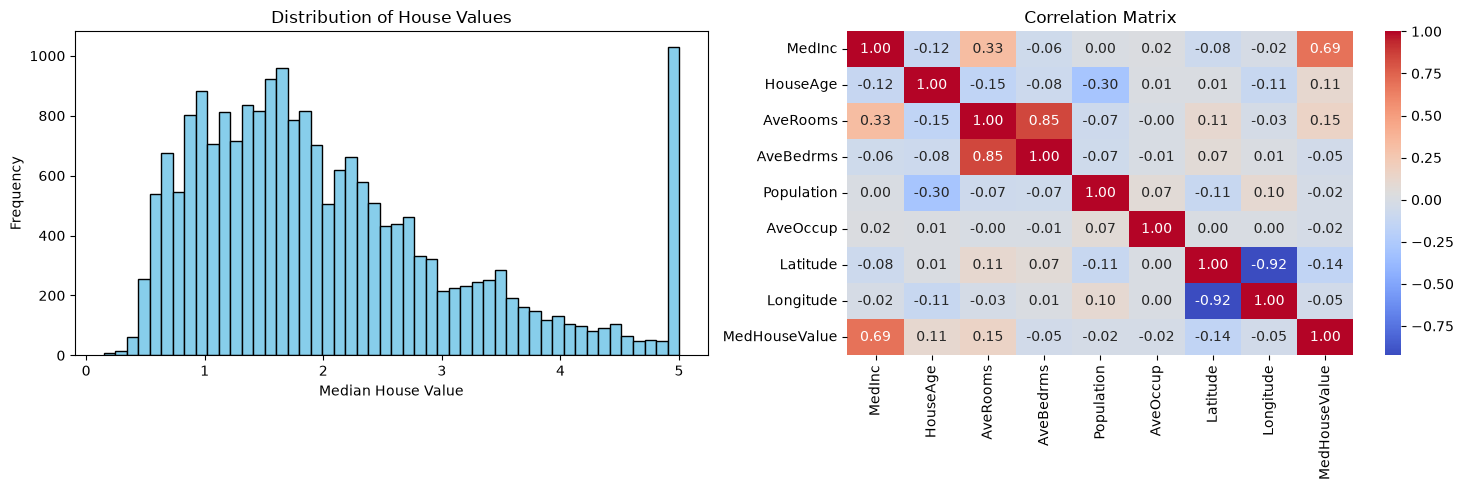

In [ ]:
# Cell 4: Visualize the target and correlations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of target
axes[0].hist(df['MedHouseValue'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of House Values')
axes[0].set_xlabel('Median House Value')
axes[0].set_ylabel('Frequency')

# Correlation heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1])
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [ ]:
# Cell 5: Prepare data for modeling
X = df.drop('MedHouseValue', axis=1)
y = df['MedHouseValue']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features (important for Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("✅ Data prepared!")

Training set: (16512, 8)
Testing set: (4128, 8)
✅ Data prepared!


In [ ]:
# Cell 6: Train Lasso Regression with different alpha values
alphas = [0.001, 0.01, 0.1, 1, 10]

print("Lasso Regression with Different Alphas:")
print("-" * 60)

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    y_pred = lasso.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    n_features = sum(lasso.coef_ != 0)
    print(f"Alpha = {alpha}: R² = {r2:.4f}, Features Used = {n_features}")

Lasso Regression with Different Alphas:
------------------------------------------------------------
Alpha = 0.001: R² = 0.5769, Features Used = 8
Alpha = 0.01: R² = 0.5816, Features Used = 7
Alpha = 0.1: R² = 0.4814, Features Used = 3
Alpha = 1: R² = -0.0002, Features Used = 0
Alpha = 10: R² = -0.0002, Features Used = 0


In [ ]:
# Cell 7: Train best Lasso model
best_alpha = 0.01
lasso_best = Lasso(alpha=best_alpha, max_iter=10000)
lasso_best.fit(X_train_scaled, y_train)

# Predictions
y_pred_lasso = lasso_best.predict(X_test_scaled)

# Metrics
mse = mean_squared_error(y_test, y_pred_lasso)
r2 = r2_score(y_test, y_pred_lasso)

print(f"Best Alpha: {best_alpha}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# Feature coefficients
print("\nFeature Coefficients (Lasso):")
for feature, coef in zip(X.columns, lasso_best.coef_):
    print(f"{feature}: {coef:.4f}")

Best Alpha: 0.01
Mean Squared Error: 0.5483
R² Score: 0.5816

Feature Coefficients (Lasso):
MedInc: 0.8010
HouseAge: 0.1271
AveRooms: -0.1628
AveBedrms: 0.2062
Population: -0.0000
AveOccup: -0.0306
Latitude: -0.7901
Longitude: -0.7557


In [ ]:
# Cell 8: Compare Lasso, Linear, and Ridge
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=0.01),
    'Lasso Regression': Lasso(alpha=0.01, max_iter=10000)
}

print("Model Comparison:")
print("-" * 60)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    n_features = sum(model.coef_ != 0)
    print(f"{name}: R² = {r2:.4f}, Features Used = {n_features}")

Model Comparison:
------------------------------------------------------------
Linear Regression: R² = 0.5758, Features Used = 8
Ridge Regression: R² = 0.5758, Features Used = 8
Lasso Regression: R² = 0.5816, Features Used = 7


In [ ]:
# Cell 10: Save results
results = pd.DataFrame({
    'Feature': X.columns,
    'Lasso_Coefficient': lasso_best.coef_
})
results.to_csv('lasso_coefficients.csv', index=False)
print("✅ Results saved to lasso_coefficients.csv")


✅ Results saved to lasso_coefficients.csv


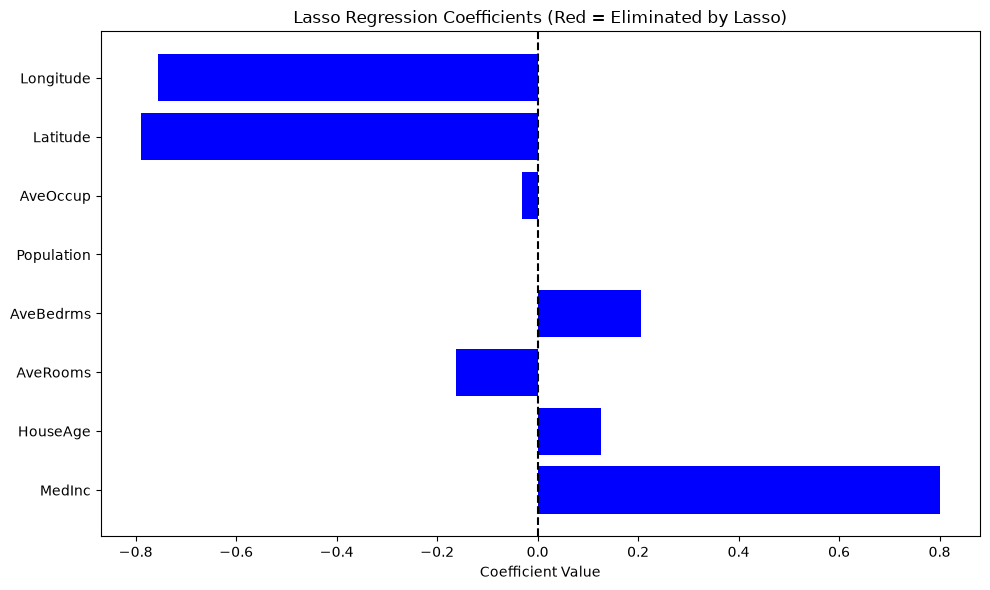

In [ ]:
# Cell 9: Visualize Lasso coefficients
plt.figure(figsize=(10, 6))
colors = ['red' if coef == 0 else 'blue' for coef in lasso_best.coef_]
plt.barh(X.columns, lasso_best.coef_, color=colors)
plt.xlabel('Coefficient Value')
plt.title('Lasso Regression Coefficients (Red = Eliminated by Lasso)')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()